In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in cleaned dataset
X_with_urn = pd.read_csv('./model_data/final_features.csv') 
y = pd.read_csv('./model_data/labels.csv')  # 1 = target, 0 = non-target

entity_urns = X_with_urn['entity_urn'].copy()

X = X_with_urn.drop(columns=['entity_urn'])

## Train / Val / Test split

In [3]:
# Separate targets and non-targets
targets = X[y.values == 1]   
non_targets = X[y.values == 0]  

In [4]:
# Split targets into Train/Val/Test manually
targets_train, targets_temp = train_test_split(
    targets, test_size=0.4, random_state=42
)
targets_val, targets_test = train_test_split(
    targets_temp, test_size=0.5, random_state=42
)

# Now split non-targets similarly
non_targets_train, non_targets_temp = train_test_split(
    non_targets, test_size=0.4, random_state=42
)
non_targets_val, non_targets_test = train_test_split(
    non_targets_temp, test_size=0.5, random_state=42
)

In [5]:
# Aggressively undersample non-targets (5x more non-targets than targets)
non_targets_train = resample(
    non_targets_train,
    replace=False,
    n_samples=len(targets_train) * 5,  # Adjust ratio here (5x, 10x etc.)
    random_state=42
)

In [6]:
# Combine targets and non-targets back
X_train = pd.concat([targets_train, non_targets_train])
y_train = pd.Series([1]*len(targets_train) + [0]*len(non_targets_train))

X_val = pd.concat([targets_val, non_targets_val])
y_val = pd.Series([1]*len(targets_val) + [0]*len(non_targets_val))

X_test = pd.concat([targets_test, non_targets_test])
y_test = pd.Series([1]*len(targets_test) + [0]*len(non_targets_test))

In [7]:
# # Shuffle each set (important so targets aren't clustered at top)
# For Train
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

train_data = X_train.copy()
train_data['label'] = y_train

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_train = train_data['label']
X_train = train_data.drop(columns=['label'])

# # For Validation
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

val_data = X_val.copy()
val_data['label'] = y_val
val_data = val_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_val = val_data['label']
X_val = val_data.drop(columns=['label'])

# # For Test
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

test_data = X_test.copy()
test_data['label'] = y_test
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_test = test_data['label']
X_test = test_data.drop(columns=['label'])

In [8]:
# Check
print("Train targets:", (y_train == 1).sum())
print("Validation targets:", (y_val == 1).sum())
print("Test targets:", (y_test == 1).sum())

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train targets: 36
Validation targets: 12
Test targets: 13
Train size: (216, 33), Validation size: (2976, 33), Test size: (2977, 33)


## Find best hyperparameters

In [9]:
# Define parameter grid
param_dist = {
    'C': np.logspace(-4, 2, 20),  # regularization strength
    'penalty': ['l2'],
    'solver': ['liblinear']
}

# 4. Hyperparameter tuning
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
random_search = RandomizedSearchCV(
    logreg,
    param_distributions=param_dist,
    scoring='average_precision',
    cv=3,
    n_iter=10,
    random_state=42
)
random_search.fit(X_train, y_train)

# Best Model
print("Best Hyperparameters:", random_search.best_params_)
print(f"Best CV AP Score: {random_search.best_score_:.4f}")


Best Hyperparameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.29763514416313164}
Best CV AP Score: 0.7389


In [10]:
# model with best hyper params
best_logreg = random_search.best_estimator_

Validation AP Score (best model): 0.1549


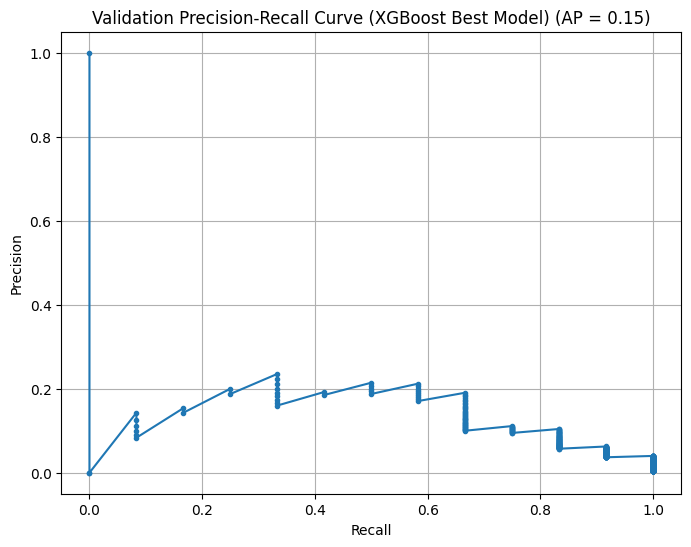

In [11]:
y_val_pred_proba = best_logreg.predict_proba(X_val)[:, 1]
ap_val = average_precision_score(y_val, y_val_pred_proba)

print(f"Validation AP Score (best model): {ap_val:.4f}")

# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title(f'Validation Precision-Recall Curve (XGBoost Best Model) (AP = {ap_val:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

## Retrain on Full Training + Validation Set

In [12]:
# Combine training and validation sets
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

# Reinitialize the model with best hyperparameters
final_logreg = LogisticRegression(
    **random_search.best_params_,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Retrain
final_logreg.fit(X_final_train, y_final_train)

LogisticRegression(C=0.29763514416313164, class_weight='balanced',
                   max_iter=1000, random_state=42, solver='liblinear')

In [13]:
y_test_pred_proba = final_logreg.predict_proba(X_test)[:, 1]
ap_test = average_precision_score(y_test, y_test_pred_proba)

print(f"Test AP Score: {ap_test:.4f}")

Test AP Score: 0.6249


In [14]:
# Predict similarity scores
similarity_scores = final_logreg.predict_proba(X)[:, 1]

# Attach to company IDs
scored_companies = pd.DataFrame({
    'entity_urn': entity_urns,  # update with your real ID column
    'similarity_score': similarity_scores
})

scored_companies.sort_values(by='similarity_score', ascending=False, inplace=True)

# Save results
scored_companies.to_csv('company_similarity_scores.csv', index=False)


In [15]:
scored_companies

,entity_urn,similarity_score
12040,urn:harmonic:company:795672,1.0
4,urn:harmonic:company:3928206,1.0
3,urn:harmonic:company:10819970,1.0
1,urn:harmonic:company:1990249,1.0
11688,urn:harmonic:company:1449489,1.0
...,...,...
13895,urn:harmonic:company:743014,0.0
894,urn:harmonic:company:1841930,0.0
2365,urn:harmonic:company:1775306,0.0
10846,urn:harmonic:company:1448128,0.0


In [16]:
target_company_data = pd.read_parquet('./case_study_data/target_company_data.parquet')
company_data = pd.read_parquet('./case_study_data/company_data.parquet')

In [17]:
company_data = company_data[~company_data['entity_urn'].isin(target_company_data['entity_urn'])]

In [18]:
target_company_data['is_target'] = 1
company_data['is_target'] = 0

In [19]:
company_full = pd.concat([target_company_data, company_data])

In [20]:
company_full

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count,is_target
0,urn:harmonic:company:1443095,2024-12-18,"{'domain': 'hebbia.ai', 'is_broken': False, 'u...",PRIVATE,15,2020-08-14,617.0,2076,https://linkedin.com/company/hebbia,31.10000,...,7.896774,3,0,0,7,3,2,4,80,1
1,urn:harmonic:company:1990249,2024-12-18,"{'domain': 'axionray.com', 'is_broken': False,...",PRIVATE,18,2021-01-01,<NA>,739,https://linkedin.com/company/axion-ray,0.42185,...,6.800000,1,0,0,0,5,0,9,54,1
2,urn:harmonic:company:3075425,2024-12-18,"{'domain': 'syrup.tech', 'is_broken': False, '...",PRIVATE,17,2020-07-09,<NA>,1590,https://linkedin.com/company/syrup-tech,7.30000,...,7.633333,1,0,0,1,4,0,2,38,1
3,urn:harmonic:company:10819970,2024-12-18,"{'domain': 'unstructured.io', 'is_broken': Fal...",PRIVATE,11,2022-01-01,22.0,262,https://linkedin.com/company/unstructuredio,0.42185,...,NaN,3,0,0,1,5,0,4,63,1
4,urn:harmonic:company:3928206,2024-12-18,"{'domain': 'smarterdx.com', 'is_broken': False...",PRIVATE,7,2020-01-01,<NA>,121,https://linkedin.com/company/smarterdx,5.97000,...,NaN,3,0,0,2,6,1,5,47,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,2025-01-05,"{'domain': 'theleappartners.com', 'is_broken':...",PRIVATE,21,2004-01-01,<NA>,4400,https://linkedin.com/company/the-leap-partners,0.00000,...,6.000000,0,0,0,0,0,0,0,2,0
15436,urn:harmonic:company:4501758,2025-01-03,"{'domain': 'fullcast.com', 'is_broken': False,...",ACQUIRED_OR_MERGED,4,2018-01-01,<NA>,1208,https://linkedin.com/company/datajoin,3.50000,...,-5.100000,0,0,0,0,0,0,0,0,0
15438,urn:harmonic:company:651225,2025-01-03,"{'domain': 'topquadrant.com', 'is_broken': Fal...",PRIVATE,36,2001-01-01,1795.0,1460,https://linkedin.com/company/topquadrant,0.00000,...,3.400000,0,0,0,0,0,0,2,15,0
15439,urn:harmonic:company:52637542,2025-01-06,"{'domain': 'getseam.ai', 'is_broken': False, '...",PRIVATE,11,2023-01-01,<NA>,1073,https://linkedin.com/company/seamai,5.00000,...,3.516424,1,0,0,2,0,0,2,20,0


In [21]:
company_full = company_full[['entity_urn', 'ownership_status', 'headcount', 'twitter_follower_count', 'linkedin_follower_count', 'funding_total',
                             'funding_stage', 'gpt_sector', 'domain', 'name', 'city', 'country', 'years_since_founding',
                             'investors', 'highlights', 'is_target']]

In [22]:
company_full

,entity_urn,ownership_status,headcount,twitter_follower_count,linkedin_follower_count,funding_total,funding_stage,gpt_sector,domain,name,city,country,years_since_founding,investors,highlights,is_target
0,urn:harmonic:company:1443095,PRIVATE,15,617.0,2076,31.10000,SERIES_B,None,hebbia.ai,Hebbia,New York,United States,4.347945,"[Index Ventures, Floodgate, GV (Google Venture...","[{'category': 'Venture Backed', 'company_urn':...",1
1,urn:harmonic:company:1990249,PRIVATE,18,<NA>,739,0.42185,SERIES_A,Vertical Software,axionray.com,Axion Ray,New York,United States,3.964384,"[Bessemer Venture Partners, Tinicum Venture Pa...","[{'category': 'Venture Backed', 'company_urn':...",1
2,urn:harmonic:company:3075425,PRIVATE,17,<NA>,1590,7.30000,SERIES_A,None,syrup.tech,Syrup Tech,New York,United States,4.446575,"[Harvard Business School, Accel, 2 | Twelve, G...","[{'category': 'Venture Backed', 'company_urn':...",1
3,urn:harmonic:company:10819970,PRIVATE,11,22.0,262,0.42185,SERIES_B,Data,unstructured.io,unstructured.io,San Francisco,United States,2.964384,"[Bain Capital Ventures, Databricks, MongoDB Ve...","[{'category': 'Venture Backed', 'company_urn':...",1
4,urn:harmonic:company:3928206,PRIVATE,7,<NA>,121,5.97000,SERIES_B,Healthcare Software,smarterdx.com,SmarterDx,New York,United States,4.967123,"[Flare Capital Partners, Bessemer Venture Part...","[{'category': 'Venture Backed', 'company_urn':...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,PRIVATE,21,<NA>,4400,0.00000,<NA>,NaN,theleappartners.com,Leap Partners,Nashville,United States,21.027397,[],[],0
15436,urn:harmonic:company:4501758,ACQUIRED_OR_MERGED,4,<NA>,1208,3.50000,EXITED,NaN,fullcast.com,Datajoin,Provo,United States,7.010959,"[Convoi Ventures, Sepio Capital]","[{'category': 'Venture Backed', 'company_urn':...",0
15438,urn:harmonic:company:651225,PRIVATE,36,1795.0,1460,0.00000,<NA>,NaN,topquadrant.com,TopQuadrant,Raleigh,United States,24.021918,[],[],0
15439,urn:harmonic:company:52637542,PRIVATE,11,<NA>,1073,5.00000,SEED,NaN,getseam.ai,Seam AI,San Francisco,United States,2.016438,"[f7 Ventures, Ritual Capital, Umami Capital, C...","[{'category': 'Venture Backed', 'company_urn':...",0


In [23]:
from cleanco import basename
from urlextract import URLExtract

extractor = URLExtract()

def extract_vc(highlights):
    for item in highlights:
        if item.get('category') == 'Venture Backed' and item.get('text') is not None:
            text = item['text']
            # Remove the "Backed By" prefix
            firms = text.replace('Backed By ', '')
            
            urls = extractor.find_urls(text)
            urls = [url.strip(',') for url in urls]

            firms = firms.split(', ')
            firms = [firm for firm in firms if basename(firm).strip() != '' and firm not in urls]

            # Return number of unique firms
            return firms
    return ''  # No Venture Backed category found

In [24]:
company_full['highlights'] = company_full['highlights'].apply(extract_vc)

/var/folders/df/2rjhqym53j90dc7b1qkdzqsh0000gn/T/ipykernel_37144/2651785283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_full['highlights'] = company_full['highlights'].apply(extract_vc)


In [25]:
company_full

,entity_urn,ownership_status,headcount,twitter_follower_count,linkedin_follower_count,funding_total,funding_stage,gpt_sector,domain,name,city,country,years_since_founding,investors,highlights,is_target
0,urn:harmonic:company:1443095,PRIVATE,15,617.0,2076,31.10000,SERIES_B,None,hebbia.ai,Hebbia,New York,United States,4.347945,"[Index Ventures, Floodgate, GV (Google Venture...","[Abstract Ventures, Andreessen Horowitz, Cory ...",1
1,urn:harmonic:company:1990249,PRIVATE,18,<NA>,739,0.42185,SERIES_A,Vertical Software,axionray.com,Axion Ray,New York,United States,3.964384,"[Bessemer Venture Partners, Tinicum Venture Pa...","[Amplo, Bessemer Venture Partners, Boeing, G V...",1
2,urn:harmonic:company:3075425,PRIVATE,17,<NA>,1590,7.30000,SERIES_A,None,syrup.tech,Syrup Tech,New York,United States,4.446575,"[Harvard Business School, Accel, 2 | Twelve, G...","[1686 Partners, 1984 Ventures, 2 | Twelve, Acc...",1
3,urn:harmonic:company:10819970,PRIVATE,11,22.0,262,0.42185,SERIES_B,Data,unstructured.io,unstructured.io,San Francisco,United States,2.964384,"[Bain Capital Ventures, Databricks, MongoDB Ve...","[Allison Pickens, Alumni Ventures, Artefact In...",1
4,urn:harmonic:company:3928206,PRIVATE,7,<NA>,121,5.97000,SERIES_B,Healthcare Software,smarterdx.com,SmarterDx,New York,United States,4.967123,"[Flare Capital Partners, Bessemer Venture Part...","[Bessemer Venture Partners, Flare Capital Part...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,PRIVATE,21,<NA>,4400,0.00000,<NA>,NaN,theleappartners.com,Leap Partners,Nashville,United States,21.027397,[],,0
15436,urn:harmonic:company:4501758,ACQUIRED_OR_MERGED,4,<NA>,1208,3.50000,EXITED,NaN,fullcast.com,Datajoin,Provo,United States,7.010959,"[Convoi Ventures, Sepio Capital]","[Convoi Ventures, Sepio Capital]",0
15438,urn:harmonic:company:651225,PRIVATE,36,1795.0,1460,0.00000,<NA>,NaN,topquadrant.com,TopQuadrant,Raleigh,United States,24.021918,[],,0
15439,urn:harmonic:company:52637542,PRIVATE,11,<NA>,1073,5.00000,SEED,NaN,getseam.ai,Seam AI,San Francisco,United States,2.016438,"[f7 Ventures, Ritual Capital, Umami Capital, C...","[Bessemer Venture Partners, Colle Capital, Rit...",0


In [26]:
company_full = company_full.merge(scored_companies, how="left", on="entity_urn")

In [27]:
company_full.sort_values(by='similarity_score', ascending=False)

,entity_urn,ownership_status,headcount,twitter_follower_count,linkedin_follower_count,funding_total,funding_stage,gpt_sector,domain,name,city,country,years_since_founding,investors,highlights,is_target,similarity_score
12040,urn:harmonic:company:795672,PRIVATE,1,16776.0,4201,0.42185,VENTURE_UNKNOWN,<NA>,gitkraken.com,GitKraken,Scottsdale,United States,11.021918,[],,0,1.0
4,urn:harmonic:company:3928206,PRIVATE,7,<NA>,121,5.97000,SERIES_B,Healthcare Software,smarterdx.com,SmarterDx,New York,United States,4.967123,"[Flare Capital Partners, Bessemer Venture Part...","[Bessemer Venture Partners, Flare Capital Part...",1,1.0
3,urn:harmonic:company:10819970,PRIVATE,11,22.0,262,0.42185,SERIES_B,Data,unstructured.io,unstructured.io,San Francisco,United States,2.964384,"[Bain Capital Ventures, Databricks, MongoDB Ve...","[Allison Pickens, Alumni Ventures, Artefact In...",1,1.0
1,urn:harmonic:company:1990249,PRIVATE,18,<NA>,739,0.42185,SERIES_A,Vertical Software,axionray.com,Axion Ray,New York,United States,3.964384,"[Bessemer Venture Partners, Tinicum Venture Pa...","[Amplo, Bessemer Venture Partners, Boeing, G V...",1,1.0
11688,urn:harmonic:company:1449489,PRIVATE,1,234.0,4709,0.21000,PRE_SEED,Healthcare Services,scripthealth.co,Scripted,Chicago,United States,6.019178,"[TechRise, Techstars, Christopher Deutsch]","[Christopher Deutsch, Techstars]",0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14669,urn:harmonic:company:4864635,,870,1262.0,25737,0.00000,VENTURE_UNKNOWN,Services,dvphilippines.com,D&V Philippines,Makati City,Philippines,12.887671,[],,0,NaN
14679,urn:harmonic:company:5344312,ACQUIRED_OR_MERGED,7,15.0,71,0.00000,EXITED,FinTech,mainlineprivatewealth.com,MainLine Private Wealth,Wynnewood,United States,13.898630,[],,0,NaN
14748,urn:harmonic:company:10845360,,7,<NA>,99,0.00000,VENTURE_UNKNOWN,<NA>,felixcomunity.carrd.co,Felix,Chiclayo,Peru,3.813699,[],,0,NaN
14791,urn:harmonic:company:15117973,,118,<NA>,244,0.00000,VENTURE_UNKNOWN,<NA>,alphagroup-uk.com,Cl,Livingston,United Kingdom,12.643836,[],,0,NaN


In [28]:
print(np.min(similarity_scores), np.max(similarity_scores))

0.0 1.0
